# Bernstein–Vazirani Algorithm

<>:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?


Bernstein-Vazirani Analysis: Secret = '1011'

1. Circuit Visualisation

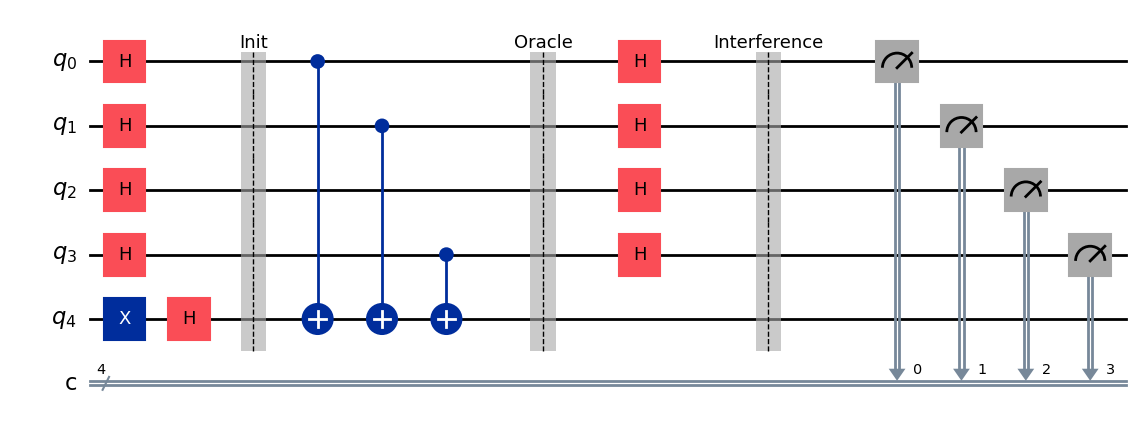

2. Unitary Evolution

Unitary matrix omitted: 4 input qubits (5 total) results in a matrix too large for clean display.


/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_25548/3814462174.py:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  print(f"The {2(n+1)}x{2(n+1)} unitary matrix describing the full circuit:")
/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_25548/3814462174.py:67: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  print(f"The {2(n+1)}x{2(n+1)} unitary matrix describing the full circuit:")


3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


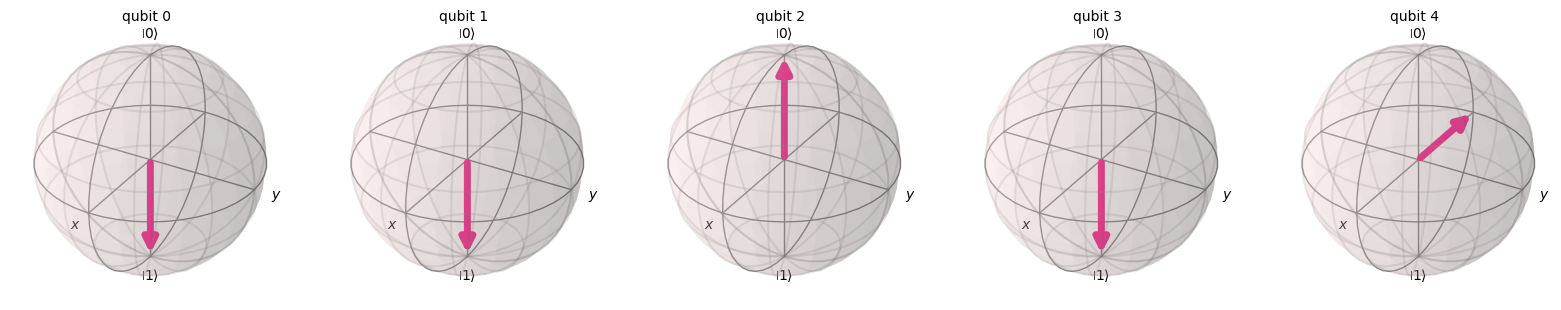


State prior to measurement (Q-Sphere):


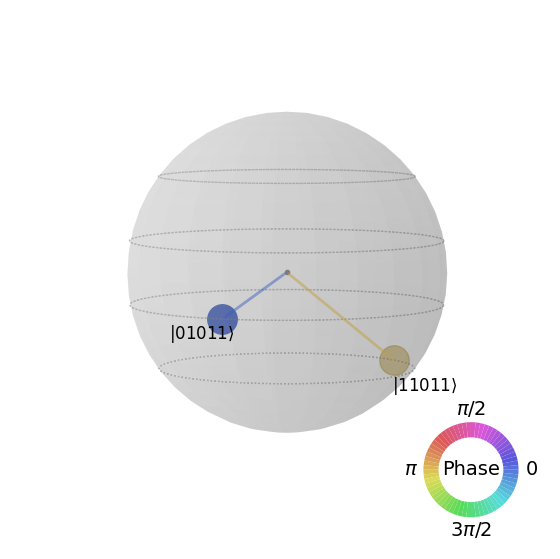

5. Measurement Analysis

Raw measurement counts: {'1011': 1024}


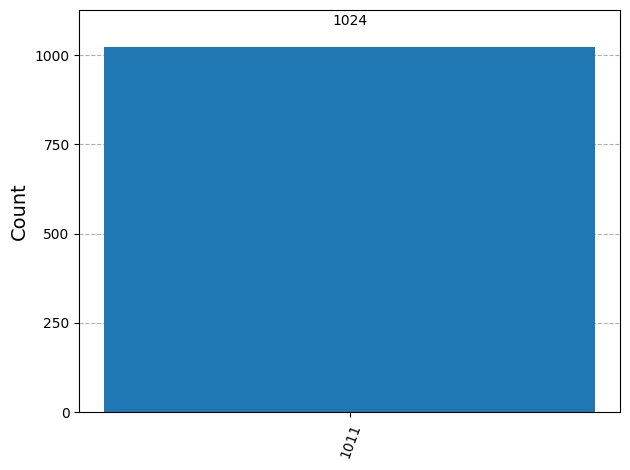

6. Verification

Success: 100% of measurements returned '1011', which perfectly matches the secret string!


In [57]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
secret_string = "1011"
n = len(secret_string)

# 1. Set up Registers & Circuit
qr = QuantumRegister(n + 1, name="q")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation
qc.x(n) # Prepare target qubit in |1>
for i in range(n + 1):
    qc.h(i) # Apply Hadamard to all qubits
qc.barrier(label="Init")

# 3. Oracle Construction (f(x) = s * x)
# Reversing string for Qiskit's endianness (q_0 is the rightmost bit)
reversed_secret = secret_string[::-1]
for qubit in range(n):
    if reversed_secret[qubit] == '1':
        qc.cx(qubit, n)
qc.barrier(label="Oracle")

# 4. Final Interference
for i in range(n):
    qc.h(i)
qc.barrier(label="Interference")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 5. Measurement (measure only the input register)
for i in range(n):
    qc.measure(i, i)

# 6. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Bernstein-Vazirani Analysis: Secret = '{secret_string}'"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
# Guardrail to prevent Jupyter output crashes on large matrices
if n <= 2: 
    print(f"The {2(n+1)}x{2(n+1)} unitary matrix describing the full circuit:")
    display(array_to_latex(unitary.data, prefix="U_{circuit} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {n} input qubits ({n+1} total) results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Verification Logic
display(Markdown("6. Verification"))
measured_bitstring = list(counts.keys())[0]

if measured_bitstring == secret_string:
    print(f"Success: 100% of measurements returned '{measured_bitstring}', which perfectly matches the secret string!")
else:
    print(f"Error: Measured '{measured_bitstring}', expected '{secret_string}'.")